In [1]:
# Import basic functionality libraries
import os
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tempfile
import shutil
import sys
import gc
import zipfile
import re
from sklearn.model_selection import train_test_split
# More specific tf import such as autotuner
from tensorflow.keras import layers
from IPython import display
import keras_tuner as kt
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D, GlobalAveragePooling2D, Dense, Activation, Input, Reshape, Multiply, AveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, ReLU, Dropout
from tensorflow.keras import Sequential

# Libraries for model optimizations
import tensorflow_model_optimization as tfmot
from keras.layers import Resizing
from tensorflow_model_optimization.quantization.keras import quantize_annotate_layer
import nbimporter
from datasets import load_dataset


2025-04-29 17:00:48.213326: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-29 17:00:49.965582: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-29 17:00:50.682003: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /share/pkg.8/python3/3.10.12/install/lib
2025-04-29 17:00:50.682017: I tensorflow/c

In [2]:
# for SCC
import tensorflow.keras as keras


In [3]:
# Setup tensorflow GPU support
use_gpu = True # set it here by hand

if use_gpu:
    # Check if GPU is available
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            # Currently, memory growth needs to be the same across GPUs
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            logical_gpus = tf.config.list_logical_devices('GPU')
            print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        except RuntimeError as e:
            # Memory growth must be set before GPUs have been initialized
            print(e)
    else:
        print("No GPU available")


No GPU available


2025-04-29 17:01:50.235423: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /share/pkg.8/python3/3.10.12/install/lib
2025-04-29 17:01:50.235620: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /share/pkg.8/python3/3.10.12/install/lib
2025-04-29 17:01:50.235781: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /share/pkg.8/python3/3.10.12/install/lib
2025-04-29 17:01:50.235922: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.

In [ ]:
import tensorflow as tf
from datasets import load_dataset
import itertools

# Load dataset in streaming mode
ds = load_dataset("Harvard-Edge/Wake-Vision", streaming=True, cache_dir='/projectnb/cs585bp/students/achetia')

input_shape = (96, 96, 3)

# Define preprocessing and augmentation
data_preprocessing = tf.keras.Sequential([
    tf.keras.layers.Resizing(input_shape[0], input_shape[1])
])

data_augmentation = tf.keras.Sequential([
    data_preprocessing,
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2)
])

# Helper: Convert and limit streaming dataset
def convert_iterable_to_tf_dataset(hf_iterable, limit):
    def gen():
        for example in itertools.islice(hf_iterable, limit):
            yield example['image'], example['person']
    
    return tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(None, None, 3), dtype=tf.uint8),
            tf.TensorSpec(shape=(), dtype=tf.int64)
        )
    )

# Convert each split with size limit
train_ds = convert_iterable_to_tf_dataset(ds['train_quality'], limit=200_000)
val_ds = convert_iterable_to_tf_dataset(ds['validation'], limit=25_000)
test_ds = convert_iterable_to_tf_dataset(ds['test'], limit=25_000)

# Batch size
batch_size = 64

# Preprocess datasets
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(tf.cast(x, tf.float32) / 255.0, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(
    lambda x, y: (data_preprocessing(tf.cast(x, tf.float32) / 255.0, training=False), y),
    num_parallel_calls=tf.data.AUTOTUNE
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(
    lambda x, y: (data_preprocessing(tf.cast(x, tf.float32) / 255.0, training=False), y),
    num_parallel_calls=tf.data.AUTOTUNE
).batch(batch_size).prefetch(tf.data.AUTOTUNE)


Resolving data files:   0%|          | 0/690 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/690 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

In [17]:
# Define the model architecture from model_centric_track.py
def create_wake_vision_model(is_training=True):
    """Creates a model for person detection based on the Wake Vision Challenge Model-Centric Track.
    
    Args:
        is_training: Boolean indicating whether the model is in training mode.
    
    Returns:
        A Keras model instance.
    """
    inputs = keras.Input(shape=input_shape)
    
    # First convolutional block
    x = keras.layers.Conv2D(8, (3,3), padding='same')(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    # Second convolutional block with pooling
    x = keras.layers.MaxPooling2D((2,2))(x)
    x = keras.layers.Conv2D(16, (3,3), padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    # Third convolutional block with pooling
    x = keras.layers.MaxPooling2D((2,2))(x)
    x = keras.layers.Conv2D(24, (3,3), padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    # Fourth convolutional block with pooling
    x = keras.layers.MaxPooling2D((2,2))(x)
    x = keras.layers.Conv2D(30, (3,3), padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    # Fifth convolutional block with pooling
    x = keras.layers.MaxPooling2D((2,2))(x)
    x = keras.layers.Conv2D(34, (3,3), padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    # Sixth convolutional block with pooling
    x = keras.layers.MaxPooling2D((2,2))(x)
    x = keras.layers.Conv2D(37, (3,3), padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    # Global average pooling
    x = keras.layers.GlobalAveragePooling2D()(x)
    
    # Dense layer
    x = keras.layers.Dense(37)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    
    # Output layer
    outputs = keras.layers.Dense(2)(x)
    
    # Create the model
    model = keras.Model(inputs, outputs, name='wake_vision_model')
    return model


In [18]:
# Create the model
model = create_wake_vision_model(is_training=True)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

# Display model summary
model.summary()


Model: "wake_vision_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 96, 96, 8)         224       
                                                                 
 batch_normalization_7 (Batc  (None, 96, 96, 8)        32        
 hNormalization)                                                 
                                                                 
 re_lu_7 (ReLU)              (None, 96, 96, 8)         0         
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 48, 48, 8)        0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 48, 48, 16)  

In [19]:
# Define a function to plot training history
def plot_training_history(history, model_index):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['sparse_categorical_accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_sparse_categorical_accuracy'], label='Validation Accuracy')
    plt.title(f'Model {model_index} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Model {model_index} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()


Epoch 1/25
1560/1562 [============================>.] - ETA: 1s - loss: 0.5176 - sparse_categorical_accuracy: 0.7448

INFO:tensorflow:Assets written to: wake_vision_model.tf/assets


INFO:tensorflow:Assets written to: wake_vision_model.tf/assets


1562/1562 [==============================] - 1398s 891ms/step - loss: 0.5176 - sparse_categorical_accuracy: 0.7448 - val_loss: 0.7021 - val_sparse_categorical_accuracy: 0.6430
Epoch 2/25
   1/1562 [..............................] - ETA: 36s - loss: 0.4685 - sparse_categorical_accuracy: 0.7500WARNING:tensorflow:Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches (in this case, 39050 batches). You may need to use the repeat() function when building your dataset.


INFO:tensorflow:Assets written to: wake_vision_model.tf/assets


INFO:tensorflow:Assets written to: wake_vision_model.tf/assets


1562/1562 [==============================] - 230s 147ms/step - loss: 0.4685 - sparse_categorical_accuracy: 0.7500 - val_loss: 0.6669 - val_sparse_categorical_accuracy: 0.6574


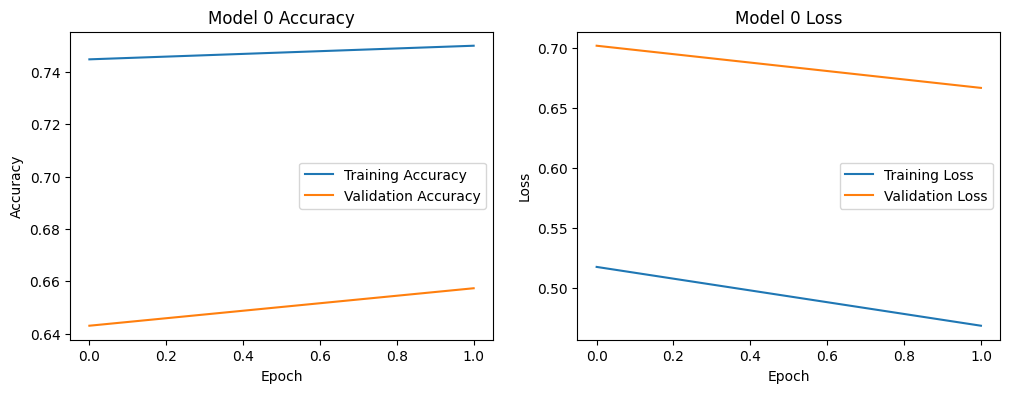

In [ ]:
# Set up model checkpoint callback for saving the best model
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath="wake_vision_model.tf",
    monitor='val_sparse_categorical_accuracy',
    mode='max',
    save_best_only=True
)

# Train the model
history = model.fit(
    train_ds,
    epochs=25, 
    validation_data=val_ds,
    steps_per_epoch=3125,
    callbacks=[
        model_checkpoint_callback,
        tf.keras.callbacks.EarlyStopping(
            monitor='val_sparse_categorical_accuracy',
            patience=5,
            restore_best_weights=True
        )
    ]
)

# Plot the training history
plot_training_history(history, 0)


In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")


In [ ]:
# Load the best model from checkpoint
best_model = tf.keras.models.load_model("wake_vision_model.tf")


In [ ]:
# Model optimization: Pruning
# Define pruning schedule
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.5,
        begin_step=0,
        end_step=1000
    )
}

# Apply pruning to the model
pruned_model = tfmot.sparsity.keras.prune_low_magnitude(best_model, **pruning_params)

# Compile the pruned model
pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

# Fine-tune the pruned model
pruned_model_history = pruned_model.fit(
    train_ds,
    epochs=5,  # Short fine-tuning
    validation_data=val_ds,
    callbacks=[
        tfmot.sparsity.keras.UpdatePruningStep(),
        tfmot.sparsity.keras.PruningSummaries()
    ]
)

# Strip pruning wrappers for deployment
stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)


In [ ]:
# Evaluate the pruned model
pruned_test_loss, pruned_test_accuracy = stripped_pruned_model.evaluate(test_ds)
print(f"Pruned model test accuracy: {pruned_test_accuracy:.4f}")


In [ ]:
# Save the pruned model
stripped_pruned_model.save("wake_vision_model_pruned")


In [ ]:
# Define a representative dataset for quantization
def representative_dataset():
    for data, _ in train_ds.take(100).unbatch().batch(1):
        yield [tf.dtypes.cast(data, tf.float32)]


In [ ]:
# Post-Training Quantization (PTQ)
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8
tflite_quant_model = converter.convert()

# Save the quantized model
with open("wake_vision_model_quantized.tflite", 'wb') as f:
    f.write(tflite_quant_model)


In [ ]:
# Function to get the size of the model file
def get_gzipped_model_size(file_path):
    # Returns size of gzipped model in bytes
    import os
    import gzip
    
    # Get model size in bytes
    model_size = os.path.getsize(file_path)
    
    # Create a gzipped version and get its size
    with open(file_path, 'rb') as f_in:
        with gzip.open(file_path + '.gz', 'wb') as f_out:
            f_out.writelines(f_in)
    
    gzipped_model_size = os.path.getsize(file_path + '.gz')
    
    # Clean up the gzipped file
    os.remove(file_path + '.gz')
    
    return model_size, gzipped_model_size


In [ ]:
# Get and display model sizes
original_size, original_gzipped_size = get_gzipped_model_size("wake_vision_model.tf")
pruned_size, pruned_gzipped_size = get_gzipped_model_size("wake_vision_model_pruned")
quantized_size = os.path.getsize("wake_vision_model_quantized.tflite")

print(f"Original model size: {original_size / 1024:.2f} KB")
print(f"Original model gzipped size: {original_gzipped_size / 1024:.2f} KB")
print(f"Pruned model size: {pruned_size / 1024:.2f} KB")
print(f"Pruned model gzipped size: {pruned_gzipped_size / 1024:.2f} KB")
print(f"Quantized model size: {quantized_size / 1024:.2f} KB")


In [ ]:
# Test the quantized TFLite model
interpreter = tf.lite.Interpreter("wake_vision_model_quantized.tflite")
interpreter.allocate_tensors()

output_details = interpreter.get_output_details()[0]
input_details = interpreter.get_input_details()[0]

# Function to evaluate the TFLite model
def evaluate_tflite_model(interpreter, test_dataset):
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    correct = 0
    total = 0
    
    for images, labels in test_dataset:
        total += len(labels)
        
        for i in range(len(images)):
            image = images[i:i+1]
            label = labels[i].numpy()
            
            # Check if the input type is quantized, then rescale input data to uint8
            if input_details['dtype'] == np.uint8:
                input_scale, input_zero_point = input_details["quantization"]
                image = image / input_scale + input_zero_point
                image = tf.cast(image, tf.uint8)
            
            interpreter.set_tensor(input_details['index'], image)
            interpreter.invoke()
            
            output = interpreter.get_tensor(output_details['index'])
            predicted_label = np.argmax(output)
            
            if predicted_label == label:
                correct += 1
    
    return correct / total

# Evaluate the quantized model
quantized_accuracy = evaluate_tflite_model(interpreter, test_ds)
print(f"Quantized TFLite model accuracy: {quantized_accuracy:.4f}")


In [ ]:
# Compare model performance vs size
model_names = ['Original', 'Pruned', 'Quantized']
model_sizes = [original_gzipped_size / 1024, pruned_gzipped_size / 1024, quantized_size / 1024]
model_accuracies = [test_accuracy, pruned_test_accuracy, quantized_accuracy]

plt.figure(figsize=(10, 6))
plt.scatter(model_sizes, model_accuracies, s=100)

for i, name in enumerate(model_names):
    plt.annotate(name, (model_sizes[i], model_accuracies[i]), 
                 xytext=(10, 5), textcoords='offset points')

plt.xlabel('Model Size (KB)')
plt.ylabel('Accuracy')
plt.title('Model Size vs. Accuracy')
plt.grid(True)
plt.show()


In [ ]:
# Export the quantized model for deployment
# Convert to C array for embedding in microcontroller code
!xxd -i wake_vision_model_quantized.tflite > wake_vision_model.cc
